## Bayesian Linear Regression – Formeln

### **ML-Schätzer**

\hat w_{\text{ML}} = (XX^\top)^{-1}Xy


### **MAP-Schätzer**
$$
\hat w_{\text{MAP}} = \left( XX^\top + \frac{\sigma_y^2}{\sigma_w^2} I \right)^{-1} X y
$$

### **Posterior-Kovarianz**
$$
\Sigma_{\text{post}} 
= \left( \sigma_y^{-2} XX^\top + \sigma_w^{-2} I \right)^{-1}
$$

### **Prädiktive Varianz**
$$
\sigma_*^2 
= \sigma_y^2 + x_*^\top \Sigma_{\text{post}} x_*
$$


In [1]:
import numpy as np

class BayesianLinearRegression:
    """
    Bayesian Linear Regression
    X shape: (D, N)
    y shape: (N,)
    sigma_y: noise std
    sigma_w: prior std
    """

    def __init__(self, sigma_y=1.0, sigma_w=1.0):
        self.sigma_y = sigma_y
        self.sigma_w = sigma_w
        self.w_ml = None
        self.w_map = None
        self.Sigma_post = None

    def fit(self, X, y):
        D, N = X.shape
        I = np.eye(D)

        # ML estimate: (XX^T)^(-1) X y
        self.w_ml = np.linalg.solve(X @ X.T, X @ y)

        # MAP estimate: (XX^T + (sigma_y^2 / sigma_w^2) I)^(-1) X y
        reg = (self.sigma_y**2 / self.sigma_w**2) * I
        self.w_map = np.linalg.solve(X @ X.T + reg, X @ y)

        # Posterior covariance
        self.Sigma_post = np.linalg.inv(
            (1 / self.sigma_y**2) * (X @ X.T) +
            (1 / self.sigma_w**2) * I
        )

        return self

    def predictive_variance(self, x_star):
        """
        x_star shape: (D,)
        Returns: predictive variance sigma_*^2
        """
        return self.sigma_y**2 + x_star.T @ self.Sigma_post @ x_star

    def predict_mean(self, x_star, use_map=True):
        """
        Predictive mean: w^T x_*
        """
        w = self.w_map if use_map else self.w_ml
        return w @ x_star


## Bayesian Kernel Regression – Formeln

Wir verwenden einen RBF-Kernel:
$$
k(x, x') = \exp\!\left(-\gamma \|x - x'\|^2\right)
$$

---

### **MAP-Schätzer**
$$
(w_{MAP}) = \alpha 
= 
\left( K + \frac{\sigma_y^2}{\sigma_w^2} I \right)^{-1} y
$$

$$
\mu_* = k_*^\top \alpha = \phi_k (x^*) \cdot w_{MAP}
$$
wobei  
$$
k_* = \begin{bmatrix}
k(x_*, x_1) \\ \vdots \\ k(x_*, x_N)
\end{bmatrix}
$$

---

### **Prädiktive Varianz**
$$
\sigma_*^2 = 
\sigma_y^2 
+ \sigma_w^2 \Big( k(x_*, x_*) - k_*^\top \tilde{K}^{-1} k_* \Big)
$$
mit  
$$
\tilde{K} = K + \frac{\sigma_y^2}{\sigma_w^2} I.
$$


In [2]:
import numpy as np

class BayesianKernelRegression:
    """
    Bayesian Kernel Regression with RBF kernel.
    
    X: training samples, shape (N, D)
    y: targets, shape (N,)
    sigma_y: noise std
    sigma_w: prior std
    """

    def __init__(self, sigma_y=1.0, sigma_w=1.0, gamma=1.0):
        self.sigma_y = sigma_y
        self.sigma_w = sigma_w
        self.gamma = gamma          # RBF kernel width parameter
        self.X = None
        self.alpha = None
        self.K_tilde = None         # K + (sigma_y^2 / sigma_w^2) I
        self.K_tilde_inv = None

    # -------------------------------------------------------
    # RBF Kernel
    # -------------------------------------------------------
    def rbf_kernel(self, A, B):
        """
        Computes the RBF kernel matrix between A and B.
        A: shape (N, D)
        B: shape (M, D)
        Returns: shape (N, M)
        """
        A_sq = np.sum(A**2, axis=1).reshape(-1, 1)
        B_sq = np.sum(B**2, axis=1).reshape(1, -1)
        sq_dists = A_sq + B_sq - 2 * A @ B.T
        return np.exp(-self.gamma * sq_dists)

    # -------------------------------------------------------
    # Fit the model
    # -------------------------------------------------------
    def fit(self, X, y):
        self.X = X
        N = X.shape[0]

        # Kernel matrix K_{ij} = k(x_i, x_j)
        K = self.rbf_kernel(X, X)

        # Compute  K̃ = K + (σ_y^2 / σ_w^2) I
        reg = (self.sigma_y**2 / self.sigma_w**2)
        self.K_tilde = K + reg * np.eye(N)

        # Compute alpha = K̃^{-1} y
        self.K_tilde_inv = np.linalg.inv(self.K_tilde)
        self.alpha = self.K_tilde_inv @ y

        return self

    # -------------------------------------------------------
    # Predictive mean μ*
    # -------------------------------------------------------
    def predict_mean(self, x_star):
        k_star = self.rbf_kernel(self.X, x_star.reshape(1, -1))  # shape (N, 1)
        return float(k_star.T @ self.alpha)

    # -------------------------------------------------------
    # Predictive variance σ*²
    # -------------------------------------------------------
    def predictive_variance(self, x_star):
        # k_* = [k(x*, x_1), ..., k(x*, x_N)]^T
        k_star = self.rbf_kernel(self.X, x_star.reshape(1, -1))  # (N, 1)

        k_xx = self.rbf_kernel(x_star.reshape(1, -1), 
                               x_star.reshape(1, -1))[0, 0]

        # σ*² = σ_y² + σ_w² ( k(x*, x*) - k_*^T K̃^{-1} k_* )
        middle = k_star.T @ self.K_tilde_inv @ k_star
        return self.sigma_y**2 + self.sigma_w**2 * (k_xx - middle)


## Bayesian Neural Networks – Laplace Approximation

Die prädiktive Varianz im Laplace-Approximationsrahmen lautet:

$$
\sigma_*^2 \approx 
\sigma_y^2 +
\nabla_\omega f(x_*)^\top
H^{-1}
\nabla_\omega f(x_*),
$$

wobei  
- $ f(x_*) $ die Netzwerkausgabe ist,  
- $ \nabla_\omega f(x_*) $ der Gradient wrt. aller Gewichte,  
- $ H $ die Hessian-Matrix der negativen Log-Posterior-Wahrscheinlichkeit  
  (oft approximiert durch die diagonale Gauss-Newton-Matrix).

Verwendete Diagonal-Approximation:

$$
H \approx \mathrm{diag}\left(
\sum_{(x_i,y_i)} 
\big( \nabla_\omega f(x_i) \big)^2
\right)
$$

und die prädiktive Varianz vereinfacht sich zu:

$$
\sigma_*^2 \approx 
\sigma_y^2 
+ \sum_j 
\frac{
\left( \frac{\partial f(x_*)}{\partial \omega_j} \right)^2
}{
H_{jj}
}.
$$


In [3]:
import torch
from torch.nn.utils import parameters_to_vector, vector_to_parameters

# ------------------------------------------------------------
# Helper: compute gradient wrt. all network parameters
# ------------------------------------------------------------
def grad_wrt_params(output, model):
    grads = torch.autograd.grad(output, model.parameters(),
                                retain_graph=True, create_graph=False)
    return torch.cat([g.reshape(-1) for g in grads])


# ------------------------------------------------------------
# Helper: diagonal Hessian approximation
# Applies:   H ≈ diag( sum_i (∂f/∂w_i)^2 )   (Gauss-Newton / Fisher style)
# ------------------------------------------------------------
def diagonal_hessian_approx(model, data_loader, loss_fn):
    h_diag = None

    for x, y in data_loader:
        x, y = x.to(next(model.parameters()).device), y.to(next(model.parameters()).device)

        pred = model(x)
        loss = loss_fn(pred, y)

        grads = torch.autograd.grad(loss, model.parameters(), create_graph=False)
        grad_vec = torch.cat([g.reshape(-1) for g in grads])

        if h_diag is None:
            h_diag = grad_vec.detach()**2
        else:
            h_diag += grad_vec.detach()**2

    return h_diag + 1e-8  # numerical stability


# ------------------------------------------------------------
# Main function: Bayesian NN predictive variance using Laplace Approx.
# ------------------------------------------------------------
def neural_bayesian_variance(model, x_star, sigma_y, hessian_diag):
    """
    model: trained neural network
    x_star: single input sample, shape (D,)
    sigma_y: noise std
    hessian_diag: diagonal Hessian approximation vector (torch tensor)

    Returns: scalar predictive variance
    """

    # Forward pass
    output = model(x_star.unsqueeze(0))

    # Gradient wrt. weights
    grad_vec = grad_wrt_params(output, model)

    # H^{-1} * grad
    h_inv_grad = grad_vec / hessian_diag

    # Variance formula
    var = sigma_y**2 + torch.dot(grad_vec, h_inv_grad)

    return float(var)


# Bayesian Neural Network – Laplace Approximation

## 1. Training
Trainiere ein NN $f(x;\omega)$ auf $(X,y)$ mit MSE-Loss:
$$
\mathcal{L}(\omega) = \frac{1}{N} \sum_i (f(x_i;\omega) - y_i)^2
$$
MAP-Gewichte: $\omega_\text{MAP} = \arg\min_\omega \mathcal{L}(\omega)$

## 2. Laplace Approximation
Posterior über Gewichte:
$$
p(\omega|X,y) \approx \mathcal{N}(\omega_\text{MAP}, H^{-1})
$$
Hessian diagonal approximiert hier verwendet:
$$
H \approx \text{diag}\Big(\sum_i \left(\frac{\partial f(x_i;\omega)}{\partial \omega}\right)^2\Big)
$$

## 3. Predictive Mean
$$
\mu_* \approx f(x_*;\omega_\text{MAP})
$$
- Einfach Forward-Pass durch das NN  
- Keine lineare Form $\phi(x)^T w$ mehr

## 4. Predictive Variance
$$
\sigma_*^2 \approx \sigma_y^2 + \nabla_\omega f(x_*)^\top H^{-1} \nabla_\omega f(x_*)
$$
- $\nabla_\omega f(x_*)$ = Gradient nach allen Gewichten  
- Zeigt Epistemische Unsicherheit

## 5. Vergleich

| Methode | Mean | Variance |
|---------|------|---------|
| BLR | $\phi(x)^T w$ | $\sigma_y^2 + \phi(x)^T \Sigma_\text{post} \phi(x)$ |
| Kernel | $k_*^T \alpha$ | $\sigma_y^2 + \sigma_w^2 (k(x_*,x_*) - k_*^T \tilde K^{-1} k_*)$ |
| BNN | $f(x_*;\omega_\text{MAP})$ | $\sigma_y^2 + \nabla_\omega f(x_*)^T H^{-1} \nabla_\omega f(x_*)$ |

**Fazit:** Mean rein durch NN, Varianz über Hessian der Gewichte, $\phi(x)$ entfällt.


C:\Users\User\AppData\Local\Temp\ipykernel_29736\2013277772.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(k_star.T @ self.alpha)


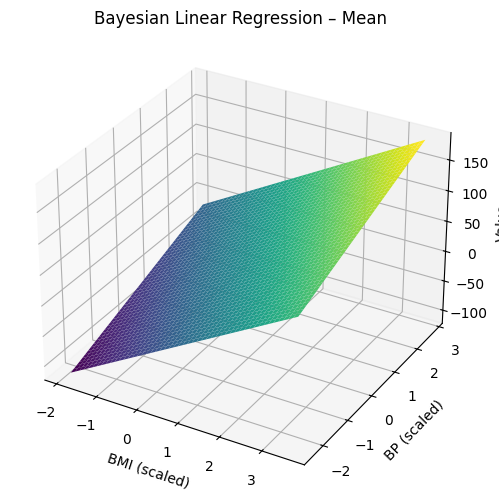

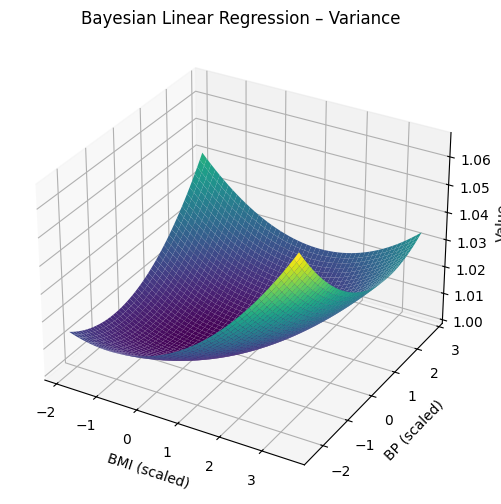

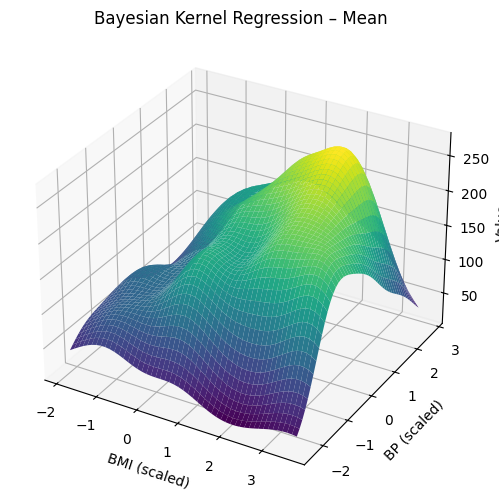

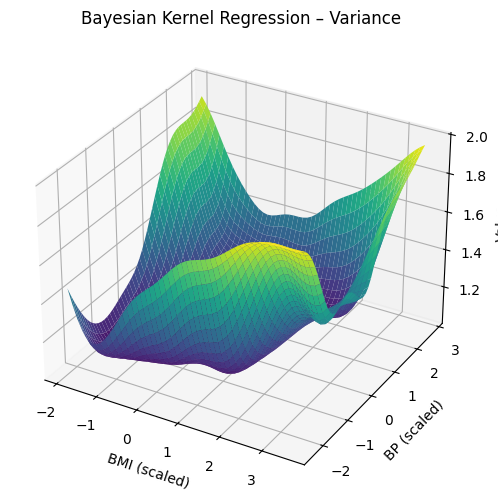

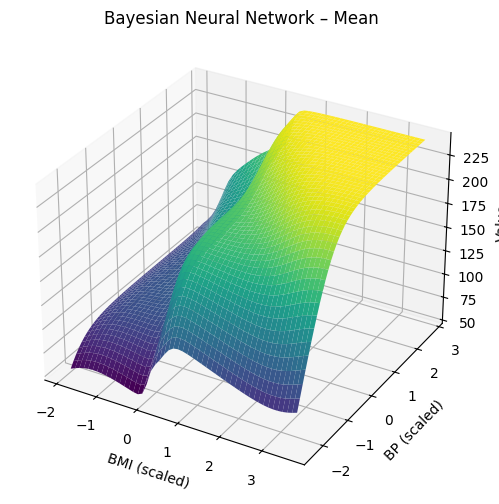

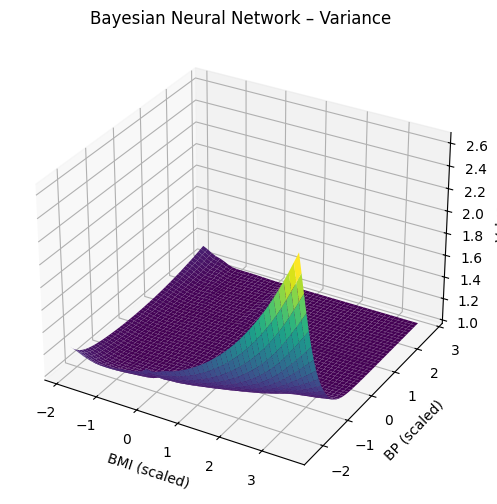

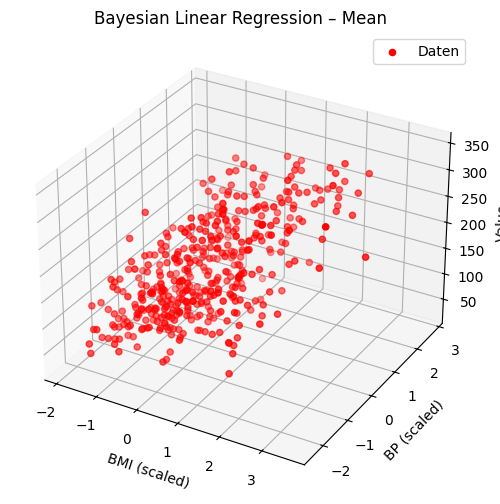

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


# ------------------------------------------------------------
# 1) Boston Housing laden (Features: RM, LSTAT)
# ------------------------------------------------------------
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

data = load_diabetes(as_frame=True)
X = data.data[["bmi", "bp"]].values  # 2 Features
y = data.target.values

scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)


N = len(X)
X_lin = X.T  # (D, N) für deine Linear-Regression-Klasse

# ------------------------------------------------------------
# 2) Grid für Visualisierung
# ------------------------------------------------------------
rm_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
lstat_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)
RM_grid, LSTAT_grid = np.meshgrid(rm_range, lstat_range)

grid_points = np.vstack([RM_grid.ravel(), LSTAT_grid.ravel()]).T


# ------------------------------------------------------------
# 3) Bayesian Linear Regression
# ------------------------------------------------------------
blr = BayesianLinearRegression(sigma_y=1.0, sigma_w=1.0)
blr.fit(X_lin, y)

mean_lin = np.array([blr.predict_mean(g) for g in grid_points])
var_lin  = np.array([blr.predictive_variance(g) for g in grid_points])


mean_lin = mean_lin.reshape(RM_grid.shape)
var_lin  = var_lin.reshape(RM_grid.shape)


# ------------------------------------------------------------
# 4) Bayesian Kernel Regression
# ------------------------------------------------------------
bkr = BayesianKernelRegression(sigma_y=1.0, sigma_w=1.0, gamma=1.0)
bkr.fit(X, y)

mean_kern = np.array([bkr.predict_mean(g) for g in grid_points])
var_kern  = np.array([bkr.predictive_variance(g) for g in grid_points])

mean_kern = mean_kern.reshape(RM_grid.shape)
var_kern  = var_kern.reshape(RM_grid.shape)


# ------------------------------------------------------------
# 5) Bayesian Neural Network (Laplace Approximation)
# ------------------------------------------------------------
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 10)
        self.fc2 = nn.Linear(10, 1)

    def forward(self, x):
        return self.fc2(torch.tanh(self.fc1(x)))

model = Net()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

loader = DataLoader(TensorDataset(X_t, y_t), batch_size=32, shuffle=True)

# Train the NN
for _ in range(600):
    for xb, yb in loader:
        optimizer.zero_grad()
        pred = model(xb) # pred von deep regression erhalten -> parameter des neuroanlen Netzes
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

# Hessian diagonal
h_diag = diagonal_hessian_approx(model, loader, loss_fn)

# Predict over grid
mean_nn = []
var_nn = []

for g in grid_points:
    gx = torch.tensor(g, dtype=torch.float32)
    with torch.no_grad():
        pred = model(gx.unsqueeze(0)).item()
    var = neural_bayesian_variance(model, gx, sigma_y=1.0, hessian_diag=h_diag)
    mean_nn.append(pred)
    var_nn.append(var)

mean_nn = np.array(mean_nn).reshape(RM_grid.shape)
var_nn  = np.array(var_nn).reshape(RM_grid.shape)


# ------------------------------------------------------------
# 6) Plotting utility
# ------------------------------------------------------------
def plot_surface(X, Y, Z, title):
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, Z, cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("BMI (scaled)")
    ax.set_ylabel("BP (scaled)")
    ax.set_zlabel("Value")
    plt.show()
def plot_surface_with_points(X_grid, Y_grid, Z_grid, X_points, Y_points, Z_points, title):
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection="3d")
    
    # Surface
    #ax.plot_surface(X_grid, Y_grid, Z_grid, cmap="viridis", alpha=0.7)
    
    # Tatsächliche Punkte
    ax.scatter(X_points, Y_points, Z_points, color="red", s=20, label="Daten")
    
    ax.set_title(title)
    ax.set_xlabel("BMI (scaled)")
    ax.set_ylabel("BP (scaled)")
    ax.set_zlabel("Value")
    ax.legend()
    plt.show()


# ------------------------------------------------------------
# 7) Visualisierung
# ------------------------------------------------------------
plot_surface(RM_grid, LSTAT_grid, mean_lin, "Bayesian Linear Regression – Mean")
plot_surface(RM_grid, LSTAT_grid, var_lin,  "Bayesian Linear Regression – Variance")

plot_surface(RM_grid, LSTAT_grid, mean_kern, "Bayesian Kernel Regression – Mean")
plot_surface(RM_grid, LSTAT_grid, var_kern,  "Bayesian Kernel Regression – Variance")

plot_surface(RM_grid, LSTAT_grid, mean_nn, "Bayesian Neural Network – Mean")
plot_surface(RM_grid, LSTAT_grid, var_nn,  "Bayesian Neural Network – Variance")
# Beispiel: Bayesian Linear Regression Mean + Datenpunkte
plot_surface_with_points(
    RM_grid, LSTAT_grid, mean_lin,
    X[:, 0], X[:, 1], y,   # Originaldaten
    "Bayesian Linear Regression – Mean"
)



# Question 2: Laplace Approximation

First we create the required 1 D dataset

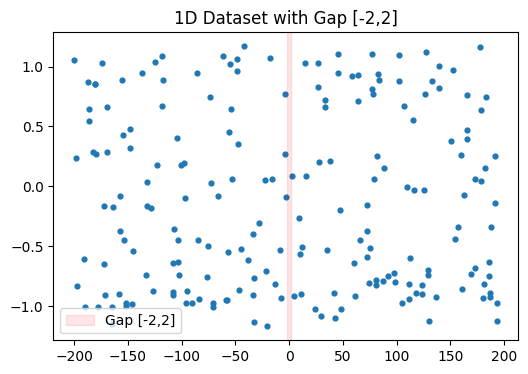

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# 1D Input
# --------
# Wir erzeugen:
#   - Daten links aus [-6, -2]
#   - Daten rechts aus [ 2,  6]
#   - Gap in [-2, 2]

n = 200

X_left  = np.random.uniform(-200, -2, size=(n//2, 1))
X_right = np.random.uniform( 2,  200, size=(n//2, 1))
X = np.vstack([X_left, X_right])

# Zielwerte (beliebige nichtlineare Funktion)
y = np.sin(X) + 0.1*np.random.randn(*X.shape)

# Plot
plt.figure(figsize=(6,4))
plt.scatter(X, y, s=12)
plt.axvspan(-2, 2, color="red", alpha=0.1, label="Gap [-2,2]")
plt.legend()
plt.title("1D Dataset with Gap [-2,2]")
plt.show()


In [28]:
import torch
from torch.autograd import grad
from torch.autograd.functional import hessian
import numpy as np


# -------------------------------------------------------------
# Helper: flatten all model gradients into a single vector
# -------------------------------------------------------------
def grad_output_wrt_params(model, x):
    """
    Computes ∇θ f(x) for scalar NN output f(x)
    returns vector shape (P,)
    """
    model.zero_grad()
    out = model(x.unsqueeze(0)).squeeze()   # scalar
    grads = torch.autograd.grad(out, model.parameters(), create_graph=False)
    return torch.cat([g.reshape(-1) for g in grads])


def flatten_params(model):
    return torch.cat([p.reshape(-1) for p in model.parameters()])


# -------------------------------------------------------------
# EMPIRICAL FISHER (FULL MATRIX)
# -------------------------------------------------------------
def empirical_fisher_full(model, X, lam=1e-3, device='cpu'):
    model.to(device)
    P = sum(p.numel() for p in model.parameters())
    F = torch.zeros((P, P), dtype=torch.float64, device=device)

    for i in range(X.shape[0]):
        g = grad_output_wrt_params(model, X[i].to(device)).double()
        F += torch.outer(g, g)

    F += lam * torch.eye(P, dtype=torch.float64, device=device)

    Sigma = torch.inverse(F)

    return F.detach().cpu().numpy(), Sigma.detach().cpu().numpy()


# -------------------------------------------------------------
# EXACT HESSIAN FULL
# -------------------------------------------------------------
def exact_hessian_full(model, X, Y, loss_fn, device='cpu'):
    model.to(device)
    params = list(model.parameters())

    theta0 = flatten_params(model).detach().double()

    def L_theta(theta_flat):
        offset = 0
        for p in params:
            n = p.numel()
            with torch.no_grad():
                p.copy_(theta_flat[offset:offset+n].view_as(p))
            offset += n

        out = model(X.to(device))
        loss = loss_fn(out, Y.to(device))
        return loss.sum()

    H = hessian(L_theta, theta0)
    H = hessian(L_theta, theta0)
    H_damped = H + 1e-3 * torch.eye(H.shape[0], dtype=H.dtype)
    Sigma = torch.inverse(H_damped) # verwende kleine regularisierung, da H sonst singulär

    return H.detach().cpu().numpy(), Sigma.detach().cpu().numpy()





In [29]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 10)
        self.fc2 = nn.Linear(10, 1)

    def forward(self, x):
        return self.fc2(torch.tanh(self.fc1(x)))

model = Net()        # dein 1D-NN
loss_fn = torch.nn.MSELoss()
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)


In [34]:
F, Sigma_F = empirical_fisher_full(model, X_tensor, lam=1e-3)
print("Fisher:", F)

H, Sigma_H = exact_hessian_full(model, X_tensor, Y_tensor, loss_fn)
print("Hessian:", H)


Fisher: [[ 4.84220945e+01 -1.60124204e+00 -3.89377928e+00  9.67990373e+00
   1.08200120e-01  4.21091318e-01  8.21563593e+00 -3.47316898e+00
  -3.26491154e+01  9.25872410e+00  1.25126097e+01 -5.54201833e-01
  -6.78164535e-01  2.31490128e+00 -3.78941425e-03  1.20753353e-01
   2.44636914e+00 -1.86738535e-01 -7.37291230e+00  1.24106679e+00
   3.58187666e+01 -7.43461780e+01 -6.69636584e+01 -2.96372883e+01
  -7.49729026e+01  7.43314703e+01 -6.44066529e+01 -6.79385541e+01
  -8.68352592e+00 -6.81660148e+01 -6.18294070e+01]
 [-1.60124204e+00  1.75767734e-01  2.10005959e-01 -2.89282600e-01
  -1.17545585e-02 -4.17674505e-02 -4.94481543e-01  1.86775061e-01
   7.79194369e-01 -5.19234897e-01 -5.54201836e-01  6.94860140e-02
   4.04652942e-02 -9.09330171e-02  4.32317839e-04 -1.38391322e-02
  -1.83998784e-01  8.61497162e-03  2.33269887e-01 -7.25503172e-02
  -6.18096679e-01  2.69876056e+00  2.21648071e+00  5.97446782e-01
   2.78137817e+00 -2.70910056e+00  1.92193954e+00  2.27291421e+00
   5.07172286e-01

In [35]:
def linearized_predictive_variance(model, x, Sigma):
    """
    Computes σ_pred^2(x) = g^T Σ g
    model : trained NN
    x     : tensor shape (1, D)
    Sigma : covariance matrix (P x P) as numpy array
    """
    # Gradient wrt model parameters
    g = grad_output_wrt_params(model, x.squeeze()).detach().numpy()  # (P,)

    # Compute variance
    var = g.T @ Sigma @ g

    return float(var)
x_test = torch.tensor([[0.5]], dtype=torch.float32)   # Beispielpunkt

var_fisher = linearized_predictive_variance(model, x_test, Sigma_F)
var_hessian = linearized_predictive_variance(model, x_test, Sigma_H)

print("Fisher predictive variance:", var_fisher)
print("Hessian predictive variance:", var_hessian)


Fisher predictive variance: 61.507644301154286
Hessian predictive variance: 3319.807843113762


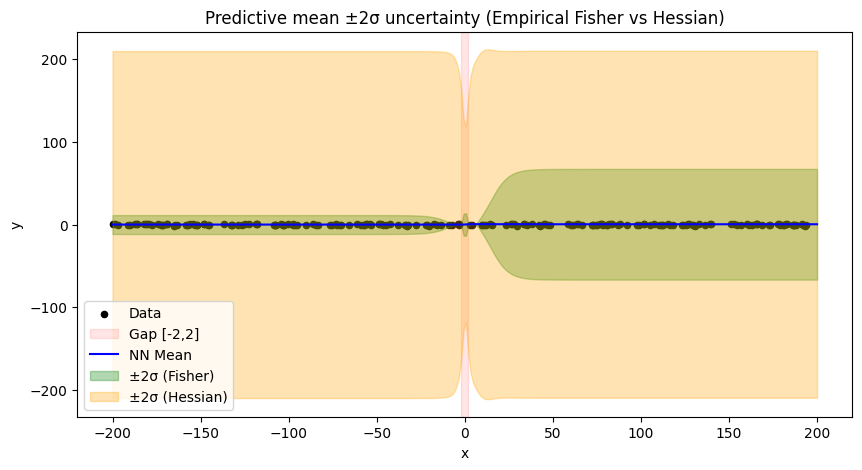

In [39]:
# x_grid: dichtes Grid für Plot
x_grid = np.linspace(-200, 200, 300)
x_tensor = torch.tensor(x_grid, dtype=torch.float32)

# Funktionen für predictive variance
def linearized_variance(model, Sigma, x):
    g = grad_output_wrt_params(model, x).detach().numpy()
    return float(g.T @ Sigma @ g)

# Compute mean and variance for grid
y_mean = []
y_upper_F = []
y_lower_F = []
y_upper_H = []
y_lower_H = []

for x in x_tensor:
    # Predictive mean
    model.eval()
    with torch.no_grad():
        y_pred = model(x.unsqueeze(0)).item()
    y_mean.append(y_pred)

    # Predictive variance Fisher
    var_F = linearized_variance(model, Sigma_F, x)
    y_upper_F.append(y_pred + 2*np.sqrt(var_F))
    y_lower_F.append(y_pred - 2*np.sqrt(var_F))

    # Predictive variance Hessian
    var_H = linearized_variance(model, Sigma_H, x)
    y_upper_H.append(y_pred + 2*np.sqrt(var_H))
    y_lower_H.append(y_pred - 2*np.sqrt(var_H))

plt.figure(figsize=(10,5))
# Original data
plt.scatter(X, y, color='black', s=20, label="Data")
plt.axvspan(-2, 2, color="red", alpha=0.1, label="Gap [-2,2]")

# Predictive mean
plt.plot(x_grid, y_mean, color='blue', label="NN Mean")

# Empirical Fisher ±2σ
plt.fill_between(x_grid, y_lower_F, y_upper_F, color='green', alpha=0.3, label="±2σ (Fisher)")

# Hessian ±2σ
plt.fill_between(x_grid, y_lower_H, y_upper_H, color='orange', alpha=0.3, label="±2σ (Hessian)")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Predictive mean ±2σ uncertainty (Empirical Fisher vs Hessian)")
plt.show()



## 📝 Unsicherheitsabschätzung in Bayes'schen Neuronalen Netzen (BNN)


### 1. Das Problem im Daten-Gap (Out-of-Distribution, OOD) 📉📈

Das Kernproblem ist die Diskrepanz zwischen der Unsicherheitsabschätzung in Regionen mit und ohne Trainingsdaten.

| Methode | Kovarianz ($\mathbf{\Sigma}$) | Verhalten im Gap | Ursache |
| :--- | :--- | :--- | :--- |
| **Empirical Fisher** ($\mathbf{F}_{\text{emp}}$) | $\mathbf{\Sigma} \approx \mathbf{F}_{\text{emp}}^{-1}$ | **Falsch niedrig** (Pathologisch) | Basiert nur auf **Gradienten an den Trainingsdatenpunkten**. Im Gap fehlt Evidenz, was zu einer Unterschätzung der Unsicherheit führt. |
| **Hessian** ($\mathbf{H}$) | $\mathbf{\Sigma} \approx \mathbf{H}^{-1}$ | **Korrekterweise hoch** | Erfasst die **Krümmung der gesamten Verlustoberfläche**. Im Gap ist die Oberfläche flach (kleine Eigenwerte), was korrekterweise zu hoher Varianz führt. |

#### 1.1. Empirical Fisher Limitation

Die **Empirical Fisher Information Matrix** ist ausschließlich datenabhängig:
$$\mathbf{F}_{\text{emp}}=\frac{1}{N}\sum_{i=1}^{N}\nabla_{\theta}\ell(x_i,y_i)\nabla_{\theta}\ell(x_i,y_i)^T$$
Da die OOD-Eingabe $x_{\text{test}}$ nicht in der Summe enthalten ist, liefert die Matrix keine Information über die Unsicherheit des Modells dort.

---

### 2. Die Notwendigkeit der Dämpfung für die Hessian 🔧

Obwohl die Hessian-Approximation ($\mathbf{H}$) theoretisch das korrekte Verhalten im Gap zeigt, muss sie für die praktische Anwendung korrigiert werden.

#### 2.1. Gründe für die Korrektur

1.  **Negative Eigenwerte:** Die Hessian kann negative Eigenwerte aufweisen, was zu einer ungültigen **nicht-positiv definiten Kovarianzmatrix** $\mathbf{\Sigma}$ führen würde.
2.  **Numerische Instabilität:** Sehr kleine Eigenwerte nahe Null (typisch für überparametrierte Netze) führen zu absurd großen Varianzschätzungen und numerischen Fehlern bei der Inversion.

#### 2.2. Die Lösung: Eigenwert-Klammerung (Damping)

Durch die Zugabe eines kleinen **Dämpfungsfaktors $\lambda$** (äquivalent zu Ridge-Regularisierung) wird die Stabilität gewährleistet.

Die korrigierte Hessian $\tilde{\mathbf{H}}$ lautet:
$$\tilde{\mathbf{H}} = \mathbf{H} + \lambda \mathbf{I}$$

* **Funktion:** Alle Eigenwerte ($\nu_i$) von $\mathbf{H}$ werden um $\lambda$ verschoben ($\tilde{\nu}_i = \nu_i + \lambda$).
* **Ergebnis:** Negative Eigenwerte werden positiv, und die kleinsten Eigenwerte werden auf mindestens $\lambda$ gesetzt. Dies stabilisiert die Inversion $\mathbf{\Sigma} \approx \tilde{\mathbf{H}}^{-1}$, da die maximale Varianz auf $1/\lambda$ begrenzt wird.